# Where do we solve the Barolcinic Rossby Radius?

In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45679,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 251.20 GiB
Comm: tcp://127.0.0.1:45291,Total threads: 4
Dashboard: /proxy/44919/status,Memory: 35.89 GiB
Nanny: tcp://127.0.0.1:33497,


## Definitions

We will calculate the $1^{st}$ baroclinic rossby radius, defined here by...

$$
  L_{br}= \frac{N H}{f_0}
$$

$$
  L_g= \frac{(gH)^{0.5}}{f_0}
$$

Where $N$ is the Brunt-Vaissala frequency, $H$ is the ocean depth and $f_0$ is the coriolis frequency

Lets calculate these...

## **Part 1**: Calculating terms

#### Coriolis parameter $f_0$

In [3]:
import gsw
session = cc.database.create_session()
lat_range=slice(-90,-59)

In [4]:
#importing
lat_01 = cc.querying.getvar("panant-01-zstar-ACCESSyr2",'thetao',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).isel(time=0,z_l=0)
lat_01=(lat_01*0 +lat_01.yh).load()
lat_005 = cc.querying.getvar("panant-005-zstar-ACCESSyr2",'thetao',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).isel(time=0,z_l=0)
lat_005=(lat_005*0 +lat_005.yh).load()
lat_0025 = cc.querying.getvar("panant-0025-zstar-ACCESSyr2",'thetao',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).isel(time=0,z_l=0)
lat_0025=(lat_0025*0 +lat_0025.yh).load()
#calculating coriolis parameter
f_01=gsw.f(lat_01)
f_005=gsw.f(lat_005)
f_0025=gsw.f(lat_0025)

#### Ocean depth a t-cells $H$

In [5]:
#importing, and replacing mid-depth to depth of bottom cell
z_i = cc.querying.getvar("panant-01-zstar-ACCESSyr2",'z_i',session,n=1)[1:]

H_01 = cc.querying.getvar("panant-01-zstar-ACCESSyr2",'thetao',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).isel(time=0)
H_01['z_l']=np.array(z_i)

H_005 = cc.querying.getvar("panant-005-zstar-ACCESSyr2",'thetao',session,n=11, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).isel(time=0)
H_005['z_l']=np.array(z_i)

H_0025 = cc.querying.getvar("panant-0025-zstar-ACCESSyr2",'thetao',session,n=11, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).isel(time=0)
H_0025['z_l']=np.array(z_i)
# getting the depth at the botom
H_01 = H_01*0 +H_01.z_l
H_01 =H_01.max("z_l").load()

H_005 = H_005*0 +H_005.z_l
H_005 =H_005.max("z_l").load()

H_0025 = H_0025*0 +H_0025.z_l
H_0025 =H_0025.max("z_l").load()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.07/lib/python3.10/site-packages/dask/array/reductions.py:653: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


#### Brunt-Vaissala frequency $f_0$

In [6]:
#First we need to import  temperature,salinity and depth (i  meters = pressure in db)
start_time='2000-01'
end_time='2000-12'
time_slice=slice(start_time,end_time)


#importing temperature
T_01 = cc.querying.getvar("panant-01-zstar-ACCESSyr2",'thetao',session,frequency='1 monthly'\
                          , chunks={'yh': '200MB', 'xh': '200MB'}\
                          ,start_time=start_time,end_time=end_time).sel(time=time_slice).sel(yh=lat_range).mean('time').load()

T_005 = cc.querying.getvar("panant-005-zstar-ACCESSyr2",'thetao',session,frequency='1 monthly'\
                           , chunks={'yh': '200MB', 'xh': '200MB'}\
                           ,start_time=start_time,end_time=end_time).sel(yh=lat_range).mean('time').load()

# T_0025 = cc.querying.getvar("panant-0025-zstar-ACCESSyr2",'thetao',session,frequency='1 monthly'\
#                             , chunks={'yh': '200MB', 'xh': '200MB'}\
#                             ,start_time=start_time,end_time=end_time).sel(yh=lat_range).mean('time').load()


#importing Salinity
S_01 = cc.querying.getvar("panant-01-zstar-ACCESSyr2",'so',session,frequency='1 monthly'\
                          , chunks={'yh': '200MB', 'xh': '200MB'}\
                          ,start_time=start_time,end_time=end_time).sel(time=time_slice).sel(yh=lat_range).mean('time').load()

S_005 = cc.querying.getvar("panant-005-zstar-ACCESSyr2",'so',session,frequency='1 monthly'\
                           , chunks={'yh': '200MB', 'xh': '200MB'}\
                           ,start_time=start_time,end_time=end_time).sel(yh=lat_range).mean('time').load()

# S_0025 = cc.querying.getvar("panant-0025-zstar-ACCESSyr2",'so',session,frequency='1 monthly'\
#                             , chunks={'yh': '200MB', 'xh': '200MB'}\
#                             ,start_time=start_time,end_time=end_time).sel(yh=lat_range).mean('time').load()


#Depth(m)/pressure(dbar) is then...
P_01= S_01*0 + S_01.z_l
P_005= S_005*0 + S_005.z_l
# P_0025= S_0025*0 + S_0025.z_l

In [8]:
#Brunt vaissala frequency will be
N_01 = np.sqrt(gsw.Nsquared(S_01,T_01,P_01,lat_01)[0])
del S_01,T_01,P_01
N_01=np.nanmean(N_01,axis=0)

N_005 = np.sqrt(gsw.Nsquared(S_005,T_005,P_005,lat_005)[0])
del S_005,T_005,P_005
N_005=np.nanmean(N_005,axis=0)

# N_0025 = np.sqrt(gsw.Nsquared(S_0025,T_0025,P_0025,lat_0025)[0])
# del S_0025,T_0025,P_0025
# N_0025=np.nanmean(N_0025,axis=0)


## **Part 2**: Rossby Radius - $L_g$

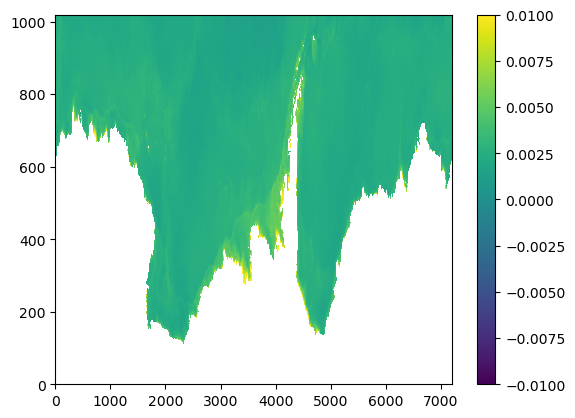

In [9]:
plt.pcolormesh(N_005,vmin=-0.01,vmax=0.01)
plt.colorbar()

I will calculate this for all resolutions as a check. But they should all be the same when plotted!

In [10]:
Lg_01=((9.81*H_01)**(0.5))/-f_01
Lg_005=((9.81*H_005)**(0.5))/-f_005
Lg_0025=((9.81*H_0025)**(0.5))/-f_0025


In [11]:
# #Checking, are they similar as they should?
# plt.figure(figsize=(10,8))
# plt.subplot(3,1,1)
# Lg_01.plot()
# plt.subplot(3,1,2)
# Lg_005.plot()
# plt.subplot(3,1,3)
# Lg_0025.plot()

Lets get the thickness of cells to compare with the Rossby Radius

In [12]:
#Importing cell thickness
dxt_01 = cc.querying.getvar("panant-01-zstar-ACCESSyr2",'dxt',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).load()
dxt_005 = cc.querying.getvar("panant-005-zstar-ACCESSyr2",'dxt',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).load()
dxt_0025 = cc.querying.getvar("panant-0025-zstar-ACCESSyr2",'dxt',session,n=1, chunks={'yh': '200MB', 'xh': '200MB'}).sel(yh=lat_range).load()

#Fixing so the matrices are continuos
dxtlong= np.array(dxt_01.sel(xh=-170,method='nearest').drop('xh'))
dxtlong=  (np.tile(dxtlong,[3600,1]).T)
dxt_01.values=dxtlong

dxtlong= np.array(dxt_005.sel(xh=-170,method='nearest').drop('xh'))
dxtlong=  (np.tile(dxtlong,[7200,1]).T)
dxt_005.values=dxtlong

dxtlong= np.array(dxt_0025.sel(xh=-170,method='nearest').drop('xh'))
dxtlong=  (np.tile(dxtlong,[14400,1]).T)
dxt_0025.values=dxtlong

Defining the solving line, which is the Rossby radius over the cell thcikness. IF the solving line value >1, then the Rossby radius is bigger than the cell thickness, and therefore eddy dynamics would be solved. opposite for values <0

In [13]:
# Line_01=Lg_01/dxt_01
# Line_005=Lg_005/dxt_005
# Line_0025=Lg_0025/dxt_0025

Now let's plot the solving line agains the topography and compare with the location of the 1km isobath

In [14]:
# #Checking, are they similar as they should?
# plt.figure(figsize=(10,8))

# #plt.subplot(3,1,1)
# H_01.plot(cmap='twilight')
# plt.contour(H_01.xh,H_01.yh,H_01,[1000],colors='black')
# plt.contour(Line_01.xh,Line_01.yh,Line_01,[1],colors='green')

## **Part 2**: Rossby Radius - $L_{br}$

In [15]:
#Approximate values of N
N=0.0025

Lap_01=(N*H_01/-f_01)
Lap_005=(N*H_005/-f_005)
Lap_0025=(N*H_0025/-f_0025)

In [17]:
L_01=(N_01*H_01/-f_01)
L_005=(N_005*H_005/-f_005)


In [18]:
# when LGNmean, the baroclinic rossby radius is solved
LNmean_01=Lap_01/(dxt_01)
LNmean_005=Lap_005/(dxt_005)
LNmean_0025=Lap_0025/(dxt_0025)

NameError: name 'Line_01' is not defined

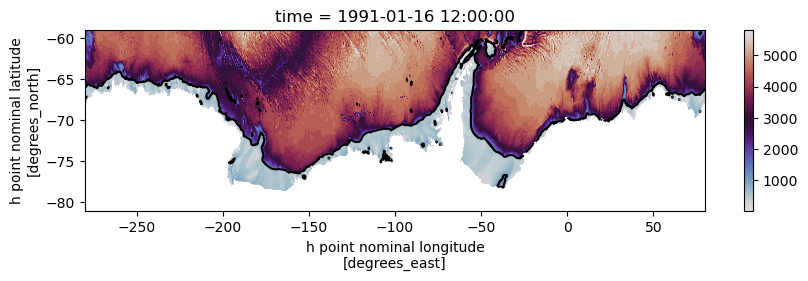

In [19]:
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
H_01.plot(cmap='twilight')
plt.contour(H_01.xh,H_01.yh,H_01,[1000],colors='black')
plt.contour(Line_01.xh,Line_01.yh,LNmean_01,[1],colors='green')

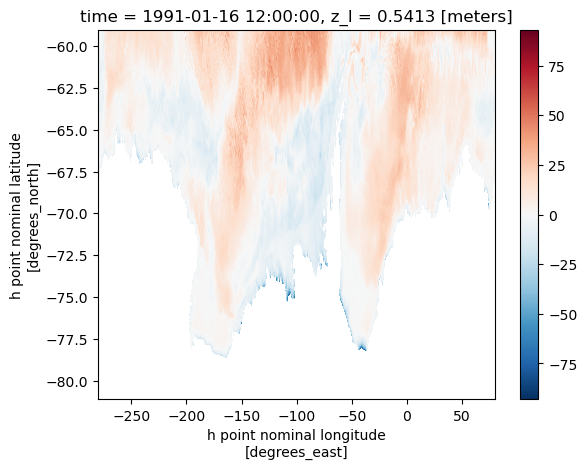

In [28]:
((Lap_01 - L_01)/1e3).plot()